# Stage 2 BBO capstone — Round 1 (Module 12)

Eight hidden functions. Each one takes a few numbers between 0 and 1 and gives back a single
number. I want that number as high as possible, but I only get one guess per function per
module, so the guesses have to count.

I'm using Bayesian optimisation: fit a model to the data I already have, get it to tell me
both what it predicts *and* how confident it is, then use both to pick where to look next.

The one thing I'm doing differently from the standard recipe is checking whether each model
is actually any good before I trust it. That check ends up changing my strategy on half the
functions.

In [3]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from scipy.stats import norm

# so I get the same answers every time I run this
np.random.seed(0)

print("imports ok")

imports ok


## Loading the data

Each function has two files: `inputs.npy` (the settings that were tried) and
`outputs.npy` (the score each one got). The notebook sits in `notebooks/` so the data
folder is one level up.

The portal only accepts inputs between 0 and 0.999999, so I'm setting those as constants now
rather than remembering them later.

In [5]:
# data folder is one level up from notebooks/
DATA = Path.cwd().parent / "data"

# portal only accepts inputs in this range
LO = 0.0
HI = 0.999999

# how many inputs each function takes
DIMS = {1: 2, 2: 2, 3: 3, 4: 4, 5: 4, 6: 5, 7: 6, 8: 8}

def load(i):
    X = np.load(DATA / f"function_{i}" / "inputs.npy")
    y = np.load(DATA / f"function_{i}" / "outputs.npy")
    return X, y

X, y = load(1)
print("function 1 inputs:", X.shape, " outputs:", y.shape)

function 1 inputs: (10, 2)  outputs: (10,)


## What am I actually starting with

Checking the sizes against the FAQ before I do anything else, because if the files are wrong
everything after this is wasted.

In [7]:
# check the sizes match the FAQ before doing anything else
rows = []
for i in range(1, 9):
    X, y = load(i)
    rows.append({
        "function": i,
        "dims": X.shape[1],
        "points": len(y),
        "lowest y": round(y.min(), 4),
        "highest y": round(y.max(), 4),
    })

pd.DataFrame(rows)

,function,dims,points,lowest y,highest y
0,1,2,10,-0.0036,0.0000
1,2,2,10,-0.0656,0.6112
2,3,3,15,-0.3989,-0.0348
3,4,4,30,-32.6257,-4.0255
4,5,4,20,0.1129,1088.8596
5,6,5,20,-2.5712,-0.7143
6,7,6,30,0.0027,1.3650
7,8,8,40,5.5922,9.5985


Sizes match the FAQ, so the data is right.

The thing that jumps out is how different the output scales are. Function 5 goes into the
thousands, and Function 1 rounds to zero at 4 decimal places. That rules out using one model
across all eight, and it means a couple of them will need a log transform before anything
will fit.

## Function 1 is broken

Looking at Function 1 on its own because the numbers looked strange in the table above.

In [10]:
# f1 looked odd above, so looking at it properly
X1, y1 = load(1)

table = pd.DataFrame({
    "x1": X1[:, 0].round(6),
    "x2": X1[:, 1].round(6),
    "y": y1,
    "log10 of size": np.log10(abs(y1)).round(1),
})
table.sort_values("log10 of size", ascending=False)

,x1,x2,y,log10 of size
4,0.650114,0.681526,-3.606063e-03,-2.4
2,0.731024,0.733000,7.710875e-16,-15.1
7,0.683418,0.861057,2.535001e-40,-39.6
1,0.574329,0.879898,1.033078e-46,-46.0
9,0.883890,0.582254,6.229856e-48,-47.2
5,0.410437,0.147554,-2.159249e-54,-53.7
0,0.319404,0.762959,1.322677e-79,-78.9
8,0.082507,0.403488,3.606771e-81,-80.4
6,0.312691,0.078723,-2.089093e-91,-90.7
3,0.840353,0.264732,3.341771e-124,-123.5


Every positive reading is zero as far as the computer is concerned. The best one is
0.00000000000000077.

So a model fitted to these values sees a completely flat surface and has nothing to work
with. This is the function I'm going to have the most trouble with.

But the last column shows the values aren't *equally* zero. They run from about -2 down to
-123, and that changes smoothly across the square. There is real information here, it's just
hiding in the exponent rather than the number itself.

Worth noting the row at the top. It's -0.0036, which is a thousand billion times bigger than
anything else here, and it's negative. Whatever is at (0.650, 0.682), I'm much closer to it
than I am to anything positive. Coming back to this.

## The model

A Gaussian process. The way I think about it: given my data points, it considers all the
curves that could reasonably pass through them, then reports the average as its prediction
and the spread as its uncertainty. Near my data it's confident, far away it admits it's
guessing.

That uncertainty is the whole point. It's what tells me where exploring might be worth it.

For the model to decide which curves count as "reasonable", it needs an assumption about how
wiggly the hidden function is allowed to be. That assumption is called the **kernel**. Two
common ones:

- **RBF** (radial basis function) assumes the function is perfectly smooth — all gentle
  curves, no sharp turns.
- **Matérn** allows it to be rougher. The `nu=2.5` setting controls how rough, and it's the
  standard middle-ground value.

I picked Matérn because RBF's assumption is too flattering. If I tell the model the function
is perfectly smooth, it becomes very sure of itself in places it has no data for, and that
confidence isn't earned. Matérn is the more cautious bet.

The other setting is the **length scale**: how far along an input do I have to move before
the output changes noticeably. Short means that input matters a lot, long means it barely
matters. I'm giving each input its own length scale rather than sharing one, so the model can
work out for itself which inputs do nothing. That helps a lot when I've got 8 inputs and only
40 points.

The `WhiteKernel` on the end is how much random noise the model is allowed to assume is in
the readings. Function 2 is the only one the brief calls noisy, so it's the only one I give
much room there.

In [13]:
# a gaussian process predicts a value AND says how unsure it is
def fit_gp(X, y, noisy=False):
    d = X.shape[1]

    # f2 is the only function described as noisy, so it gets more room here
    if noisy:
        noise = WhiteKernel(0.01, (1e-5, 1.0))
    else:
        noise = WhiteKernel(1e-6, (1e-10, 1.0))

    # matern not rbf, rbf gets over-confident where there's no data
    # one length scale per input so it can spot inputs that don't matter
    kernel = ConstantKernel(1.0) * Matern(np.full(d, 0.3), (0.01, 10), nu=2.5) + noise

    gp = GaussianProcessRegressor(kernel=kernel,
                                  normalize_y=True,
                                  n_restarts_optimizer=25,
                                  random_state=0)
    gp.fit(X, y)
    return gp

gp = fit_gp(*load(4))
print(gp.kernel_)

4.11**2 * Matern(length_scale=[1.83, 1.62, 1.84, 1.78], nu=2.5) + WhiteKernel(noise_level=1.03e-10)


## Is the model any good?

This is the bit I nearly skipped, and it turned out to matter more than anything else.

A Gaussian process will fit *any* data and produce a confident-looking surface with peaks on
it. With 15 points in 3 dimensions those peaks might be completely made up. If I chase them
and call it exploitation, I'm just fooling myself.

So: hide one data point, fit the model on the rest, get it to predict the hidden one, record
how wrong it was. Repeat for every point. Then compare against the dumbest possible model,
which is just always guessing the average.

If the answer is under 1 the model beats guessing the average, so its predictions mean
something. If it's over 1 the model is worse than a flat line and I shouldn't trust its peaks.

In [15]:
# is the model any good, or is it inventing peaks?
def loo_score(X, y, noisy=False):
    errors = []
    for i in range(len(X)):
        # take point i out
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i)

        # fit on what's left and predict the one I removed
        g = fit_gp(X_train, y_train, noisy)
        prediction = g.predict([X[i]])[0]

        errors.append((prediction - y[i]) ** 2)

    rmse = np.sqrt(np.mean(errors))

    # under 1 = beats guessing the average, over 1 = worse than a flat line
    return rmse / np.std(y)

print("f4 trust score:", round(loo_score(*load(4)), 2))

f4 trust score: 0.18


Running that for all eight. Function 1 and Function 5 get a log transform first, for the
scale reasons above. Function 2 is the only one the brief describes as noisy, so it's the only
one I let the model fit a noise term for.

This takes a few minutes because it refits the model once per data point.

In [17]:
# same check on all eight, takes a few minutes
trust = []
for i in range(1, 9):
    X, y = load(i)

    if i == 1:
        # only the positive readings, and on a log scale or they're all just zero
        X_use = X[y > 0]
        y_use = np.log(y[y > 0])
    elif i == 5:
        # log, because y goes from 0.11 up to 1089
        X_use = X
        y_use = np.log(y)
    else:
        X_use = X
        y_use = y

    score = loo_score(X_use, y_use, noisy=(i == 2))

    if score < 0.95:
        verdict = "exploit"
    else:
        verdict = "buy information"

    trust.append({"function": i, "points": len(y_use),
                  "score": round(score, 2), "verdict": verdict})

trust_df = pd.DataFrame(trust)
trust_df

,function,points,score,verdict
0,1,7,1.45,buy information
1,2,10,0.88,exploit
2,3,15,1.19,buy information
3,4,30,0.18,exploit
4,5,20,1.31,buy information
5,6,20,0.89,exploit
6,7,30,1.17,buy information
7,8,40,0.10,exploit


Half of them fail. That was not what I expected but it makes sense: 10 points in 2D and 40
points in 8D are both very thin, and no amount of clever modelling fixes not having data.

I'd rather know this than not. It means on four of the functions I should be spending this
query on gathering information, and only on the other four does exploiting the model's
prediction actually make sense.

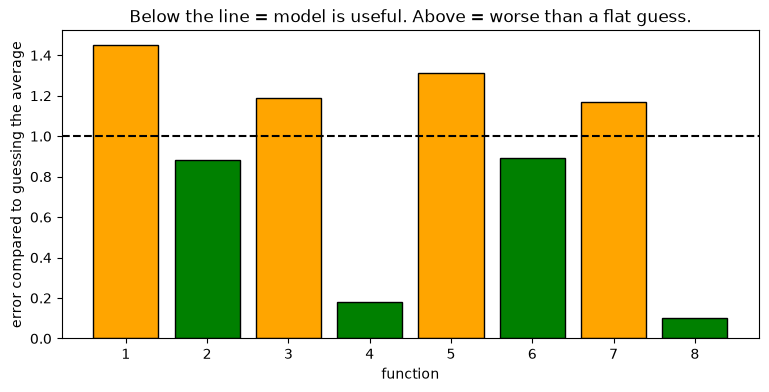

In [19]:
colours = []
for score in trust_df["score"]:
    if score < 0.95:
        colours.append("green")
    else:
        colours.append("orange")

plt.figure(figsize=(9, 4))
plt.bar(trust_df["function"], trust_df["score"], color=colours, edgecolor="black")
plt.axhline(1.0, color="black", linestyle="--")
plt.xlabel("function")
plt.ylabel("error compared to guessing the average")
plt.title("Below the line = model is useful. Above = worse than a flat guess.")
plt.savefig("../figures/trust_scores.png", dpi=150)
plt.show()

## Which inputs actually matter

Each input has its own length scale. A short one means moving along that input changes the
output a lot, so it matters. A long one means the output barely notices, so it doesn't.

Worth checking, because if the model thinks an input does nothing then nothing is pushing it
towards any particular value, and I'd end up submitting whatever number happened to come out.

In [21]:
# short length scale = that input matters, long = it does nothing
for i in range(2, 9):
    X, y = load(i)
    if i == 5:
        y_use = np.log(y)
    else:
        y_use = y

    g = fit_gp(X, y_use, noisy=(i == 2))
    lengths = g.kernel_.k1.k2.length_scale

    useless = []
    for j in range(len(lengths)):
        if lengths[j] >= 5.0:
            useless.append(j + 1)

    print("f", i, " lengths:", np.round(lengths, 2), " inputs doing nothing:", useless)

f 2  lengths: [ 0.07 10.  ]  inputs doing nothing: [2]
f 3  lengths: [10.   10.    0.08]  inputs doing nothing: [1, 2]
f 4  lengths: [1.83 1.62 1.84 1.78]  inputs doing nothing: []
f 5  lengths: [1.98 0.53 0.99 0.76]  inputs doing nothing: []
f 6  lengths: [0.86 1.64 2.06 2.13 2.17]  inputs doing nothing: []
f 7  lengths: [ 1.06 10.   10.    0.36  0.2   0.25]  inputs doing nothing: [2, 3]
f 8  lengths: [ 3.14  4.39  2.26  9.84 10.    4.48  3.12 10.  ]  inputs doing nothing: [4, 5, 8]


## Deciding where to look next

Two options, and the choice between them is exploration vs exploitation.

**Expected Improvement** asks: if I sample here, how much better than my current best do I
expect to do? It handles the trade-off on its own, because a point can score well either by
having a high predicted value or by having a lot of uncertainty around it.

**UCB** is simpler: prediction plus kappa times uncertainty. Turn kappa up to explore more.

I'm using EI where the model passed the trust check and UCB where it didn't. Reason: when the
model is unreliable, EI just runs to whichever point has the widest error bars, and that's
always a corner. UCB holds up better because the prediction still gets a say.

In [23]:
# EI: how much better than my best so far do I expect to do here?
# scores well either by predicting high OR by being uncertain
def expected_improvement(points, gp, best_so_far, xi):
    mu, sd = gp.predict(points, return_std=True)
    sd = np.maximum(sd, 1e-12)
    z = (mu - best_so_far - xi) / sd
    return (mu - best_so_far - xi) * norm.cdf(z) + sd * norm.pdf(z)

# UCB: prediction plus kappa lots of uncertainty, bigger kappa explores more
def ucb(points, gp, kappa):
    mu, sd = gp.predict(points, return_std=True)
    return mu + kappa * sd

print("ok")

ok


To find where the score is highest I just make 50,000 random points, score all of them, and
keep the best one. The course notes suggest random or grid search as perfectly acceptable
methods, and it saves me writing anything complicated.

I checked how much the answer moves if I change the random seed. On the inputs that matter it
barely moves at all. It jumps around on the inputs the model says do nothing, but I'm
overwriting those anyway in a moment.

## Back to Function 1

None of the above works here, because the model sees a flat surface and Expected Improvement
on a flat surface is meaningless.

But the description says "only proximity yields a non-zero reading". That's describing
something that fades with distance from a source:

$$y = A \cdot e^{-\|x-c\|^2 / 2s^2}$$

If I take the log of both sides the exponential disappears and I'm left with a quadratic:

$$\log y = -\frac{\|x\|^2}{2s^2} + \frac{c \cdot x}{s^2} + \text{const}$$

A quadratic I can fit exactly with least squares, and then find the peak of using the same
algebra I'd use to find the top of a parabola. No Gaussian process needed at all.

I fit it to the strongest readings only, because the weak ones are picking up a different
source and would break the assumption that there's just one.

In [42]:
# f1 needs its own method, the model sees a flat surface so EI is meaningless
# "only proximity gives a reading" means y = A * exp(-distance^2 / 2s^2)
# take logs and that's just a quadratic, which I can fit and find the top of
def locate_source_f1(X, y, k):
    # positive readings only
    X_pos = X[y > 0]
    log_y = np.log(y[y > 0])

    # the k strongest ones
    order = np.argsort(log_y)[::-1]
    idx = order[:k]

    # the four columns of the quadratic
    col1 = (X_pos[idx] ** 2).sum(axis=1)
    col2 = X_pos[idx][:, 0]
    col3 = X_pos[idx][:, 1]
    col4 = np.ones(k)
    A = np.column_stack([col1, col2, col3, col4])

    a, b, c, d = np.linalg.lstsq(A, log_y[idx], rcond=None)[0]

    # top of the quadratic
    centre = np.array([-b / (2 * a), -c / (2 * a)])
    sigma = np.sqrt(-1 / (2 * a))
    return centre, sigma

# k=4 and k=5 should agree, k=6 and k=7 should break
for k in [4, 5, 6, 7]:
    centre, sigma = locate_source_f1(X1, y1, k)
    print("strongest", k, "readings -> centre", centre.round(4), " width", round(sigma, 4))

strongest 4 readings -> centre [0.6296 0.6305]  width 0.0177
strongest 5 readings -> centre [0.6283 0.6294]  width 0.0177
strongest 6 readings -> centre [1.2288 0.6786]  width 0.0708
strongest 7 readings -> centre [1.2323 4.4381]  width 0.1232
